In [1]:
import numpy as np
import matplotlib.pyplot as plt

from Flame_fun import crop_flame_region

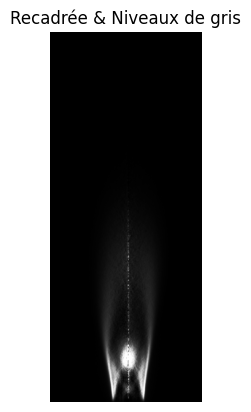

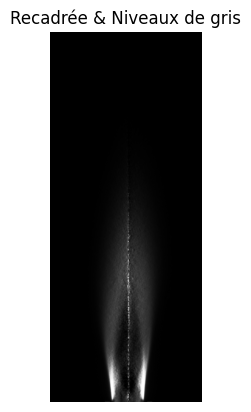

In [2]:
# Comparaison des recadrages selon les différents formats d'image
# Objectif : vérifier et ajuster le centrage des zones de recadrage

# Chemins des images à comparer (images tests)
image_1205_path = "./data/d10D15/P2S29S0.png" 
image_1219_path = "./data/d10D15/P2S6S0B.png"

# Chargement et prétraitement des images
image_test_1205px = crop_flame_region(image_1205_path)
image_test_1219px = crop_flame_region(image_1219_path)

# Affichage des images recadrées en niveaux de gris
plt.imshow(image_test_1205px, cmap='gray')
plt.title(f"Recadrée & Niveaux de gris")
plt.axis('off')
plt.show()

plt.imshow(image_test_1219px, cmap='gray')
plt.title(f"Recadrée & Niveaux de gris")
plt.axis('off')
plt.show()



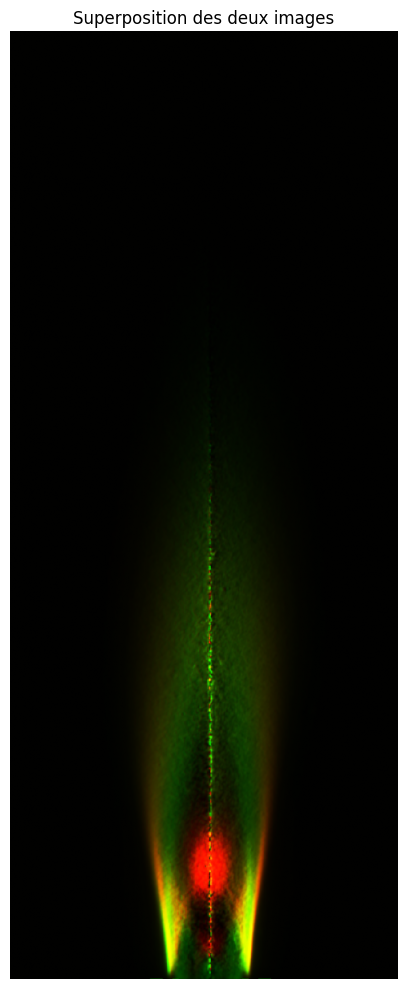

In [3]:
# Superposition des images pour vérifier l'alignement après recadrage

def compare_cropped_matrices(mat1, mat2):
    """
    Input:
        mat1 (np.ndarray): Première image 2D à comparer
        mat2 (np.ndarray): Deuxième image 2D à comparer

    Output:
        None: Affiche une superposition RGB des deux matrices
              - canal rouge : mat1
              - canal vert : mat2
    """
    
    # Vérifie que les deux images ont la même taille
    if mat1.shape != mat2.shape:
        print(f"Erreur : Impossible de superposer. Dimensions différentes : {mat1.shape} vs {mat2.shape}")
        return

    # Normalisation pour éviter qu'une image domine visuellement l'autre
    max1 = np.max(mat1) if np.max(mat1) > 0 else 1
    max2 = np.max(mat2) if np.max(mat2) > 0 else 1
    
    m1_norm = mat1.astype(float) / max1
    m2_norm = mat2.astype(float) / max2

    # Construction d'une image RGB de superposition 
    superposition = np.zeros((mat1.shape[0], mat1.shape[1], 3))
    superposition[:, :, 0] = m1_norm # Rouge
    superposition[:, :, 1] = m2_norm # Vert

    plt.figure(figsize=(6, 10))
    plt.imshow(superposition)
    plt.title("Superposition des deux images")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

compare_cropped_matrices(image_test_1205px,image_test_1219px)